=== DEBUG: DYNAMIC PCA IS BEING USED ===
vol_loadings shape: (7, 7)
First element of loadings: 0.4441

True model log(h_sim) correlations (should now match original):
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.10   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.24   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.10    -0.24       -0.06    1.00  -0.22  -0.13          0.20
sugar           0.54     0.67        0.65   -0.22   1.00   0.32          0.10
water           0.60     0.55        0.47   -0.13   0.32   1.00          0.16
tranquillity    0.15    -0.09        0.29    0.20   0.10   0.16          1.00
VALIDATION

Correlation matrix comparison:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148


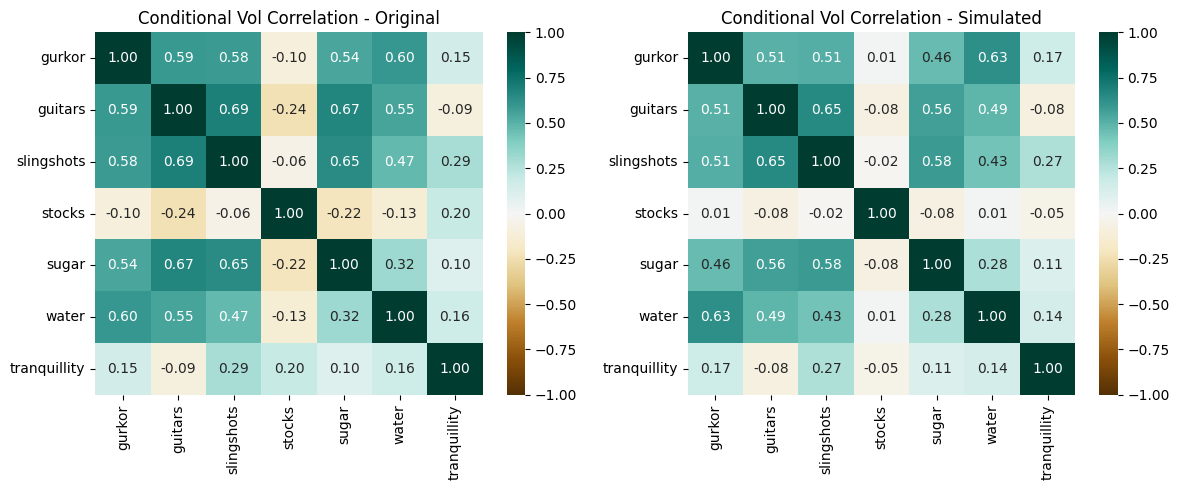


MAE of vol correlations: 0.073


In [46]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================================
# Parameters (same as before)
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# Kurtosis parameters (same as before)
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
# nu_blended = nu_target # Note: this is just for now as i am unsure of the alphas.
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}



# =============================================================================
# VOLATILITY FACTOR MODEL — COMPUTED FROM DATA (this is the ONLY version)
# =============================================================================
# 1. Fit univariate GARCH(1,1) on original data

# cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names)
# for col in var_names:
#     model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
#     res = model.fit(disp='off')
#     cond_var_og[col] = res.conditional_volatility ** 2

# 1. Fit univariate GARCH(1,1) on original data AND SAVE PARAMETERS
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names)
# Store original parameters for later filtering
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    # Save parameters for filtering simulated data
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

log_h_og = np.log(cond_var_og)
log_h_means = log_h_og.mean().values
log_h_stds  = log_h_og.std().values

log_h_std = (log_h_og - log_h_means) / log_h_stds

n_pc = 7
pca = PCA(n_components=n_pc)
pca_factors = pca.fit_transform(log_h_std)
vol_loadings = pca.components_.T

# DEBUG — this proves we are using the dynamic version
print("=== DEBUG: DYNAMIC PCA IS BEING USED ===")
print("vol_loadings shape:", vol_loadings.shape)
print("First element of loadings:", round(vol_loadings[0,0], 4))

vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors[:, k]
    X = np.column_stack((np.ones(len(factor)-1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }


og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)


# =============================================================================
# Simulation (uses the dynamic parameters above)
# =============================================================================
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + np.random.randn(7)

vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    
    # FIX: Increase persistence to reduce GARCH estimation noise
    # Map phi from [0,1] closer to 1: new_phi = 1 - 0.3*(1-phi) 
    # This keeps relative persistences but makes them all more persistent
    phi_boosted = 1 - 0.2 * (1 - abs(phi))
    if phi < 0:  # Keep negative signs if any
        phi_boosted = -phi_boosted
    
    # Adjust c to maintain same unconditional mean: c_new = c * (1-phi_new)/(1-phi)
    if abs(phi) < 0.999:
        c_adjusted = c * (1 - phi_boosted) / (1 - phi)
    else:
        c_adjusted = c
    
    # Adjust sigma to maintain same unconditional variance
    # Var = sigma^2 / (1-phi^2), so sigma_new = sigma * sqrt((1-phi_new^2)/(1-phi^2))
    sigma_adjusted = sigma * np.sqrt((1 - phi_boosted**2) / (1 - phi**2))
    
    # Initialize at unconditional mean with boosted persistence
    if abs(phi_boosted) < 1:
        vol_factors[0, k] = c_adjusted / (1 - phi_boosted)
    else:
        vol_factors[0, k] = 0
        
    for t in range(1, T_total):
        vol_factors[t, k] = c_adjusted + phi_boosted * vol_factors[t-1, k] + sigma_adjusted * np.random.randn()

# Make vol stronger:
# vol_factors[:, 2] *= 2  # Boost PC3 which loads heavily on stocks
# vol_factors[:, 4] *= 1.2  # Boost PC5 


# Standardize to exactly match target variances while preserving correlation structure
# Target covariance should be diagonal with target_std^2 on diagonal
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std']**2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
# Matrix square root correction to force exact covariance
current_cov_sqrt = np.linalg.cholesky(current_cov + np.eye(n_pc)*1e-10)
target_cov_sqrt = np.linalg.cholesky(target_cov)
transform = target_cov_sqrt @ np.linalg.inv(current_cov_sqrt)
vol_factors = vol_factors @ transform.T

log_h_std_sim = vol_factors @ vol_loadings.T
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations (should now match original):")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

# df_returns_final = pd.DataFrame(Y_final, columns=var_names)
# df_returns_final = df_returns_final.multiply(original_stds / df_returns_final.std(), axis=1)

df_returns_final = pd.DataFrame(Y_final, columns=var_names)
df_returns_final = df_returns_final.multiply(original_stds / df_returns_final.std(), axis=1)
# =============================================================================
# Validation
# =============================================================================
print("="*60)
print("VALIDATION")
print("="*60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), columns=var_names)

for col in var_names:
    params = original_garch_params[col]
    omega, alpha, beta = params['omega'], params['alpha'], params['beta']
    
    # Manually compute GARCH(1,1) conditional variances
    # sigma2_t = omega + alpha * r2_{t-1} + beta * sigma2_{t-1}
    returns = df_returns_final[col].values * 1000  # Rescale as in original
    sigma2 = np.zeros(len(returns))
    
    # Initialize at unconditional variance
    sigma2[0] = omega / (1 - alpha - beta) if (alpha + beta) < 1 else omega
    
    for t in range(1, len(returns)):
        r2_lag = returns[t-1]**2
        sigma2[t] = omega + alpha * r2_lag + beta * sigma2[t-1]
    
    cond_var_sim[col] = sigma2

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean = 'Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "="*60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("="*60)

# Fit GARCH to simulated returns, extract conditional variances
cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)))
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Fit GARCH to original returns
cond_var_og = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2

# print("\nOriginal conditional vol correlations:")
# print(np.log(cond_var_og).corr().round(2))
# print("\nSimulated conditional vol correlations:")
# print(np.log(cond_var_sim).corr().round(2))


print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og).corr().round(2))
print("\nSimulated conditional vol correlations (Original Parameters):")
print(np.log(cond_var_sim).corr().round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(np.log(cond_var_og).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

# Error metrics
og_vol_corr = np.log(cond_var_og).corr().values
sim_vol_corr = np.log(cond_var_sim).corr().values
mask = ~np.eye(7, dtype=bool)
mae = np.mean(np.abs(og_vol_corr[mask] - sim_vol_corr[mask]))
print(f"\nMAE of vol correlations: {mae:.3f}")

In [47]:
Nästa steg: skew!

SyntaxError: invalid syntax (507249967.py, line 1)

Stocks vol R² from shared factors: 0.097
Stocks coupling betas: [-0.09242833  0.25326548  0.00607701]
  Vol PC1: phi=0.9942, c=-0.0010, resid_std=0.1909, target_std=1.8188
  Vol PC2: phi=0.9929, c=0.0006, resid_std=0.1173, target_std=1.0364
  Vol PC3: phi=0.9866, c=-0.0002, resid_std=0.1406, target_std=0.8534
  Vol PC4: phi=0.9836, c=0.0001, resid_std=0.1138, target_std=0.6315
  Vol PC5: phi=0.9536, c=0.0003, resid_std=0.1668, target_std=0.5468
  Vol PC6: phi=0.9617, c=-0.0001, resid_std=0.1202, target_std=0.4376
  Stocks idio vol: phi=0.9730, resid_std=0.0356

True model log(h_sim) correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.12   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.26   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.12    -0.26       -0.06    1.00  -0.17  -0.05          0.31
sugar 

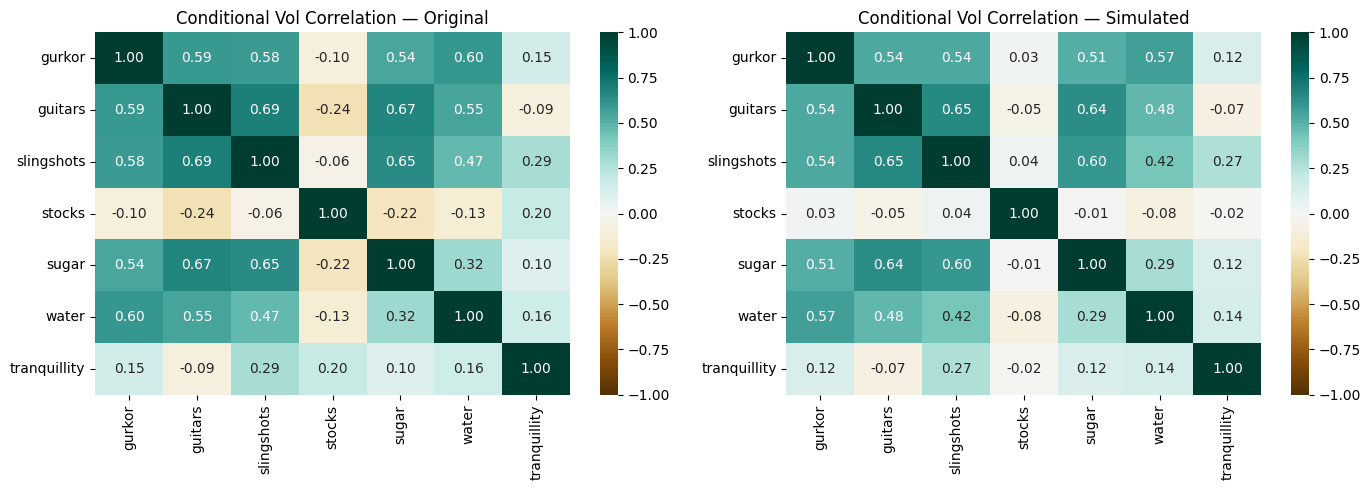

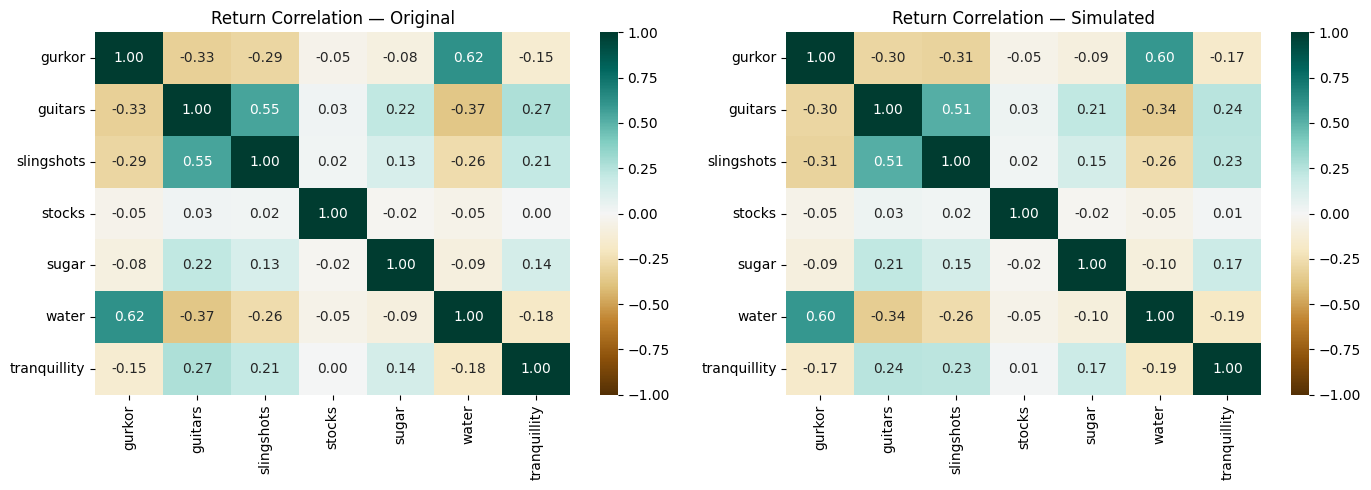

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
stocks_idx = var_names.index('stocks')
non_stock_names = [v for v in var_names if v != 'stocks']
non_stock_idx = [i for i, v in enumerate(var_names) if v != 'stocks']

# =============================================================================
# VAR(2) parameters
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis / t-distribution parameters
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# GARCH on original data — save params
# =============================================================================
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names, dtype=float)
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

# =============================================================================
# PCA on log-volatility — separate stocks from the rest
# =============================================================================
log_h_og = np.log(cond_var_og.astype(float))
log_h_means = log_h_og.mean().values
log_h_stds = log_h_og.std().values
log_h_std = (log_h_og - log_h_means) / log_h_stds

# Full PCA (used for non-stocks shared structure)
n_pc = 6  # shared factors for 6 non-stock series
pca_full = PCA(n_components=7)
pca_full.fit(log_h_std)

# Also do PCA on just the 6 non-stock series for cleaner shared factors
log_h_non_stock = log_h_std[non_stock_names]
pca = PCA(n_components=n_pc)
pca_factors_ns = pca.fit_transform(log_h_non_stock)
vol_loadings_ns = pca.components_.T  # (6, 6)

# Stocks: get its own AR(1) log-vol process
stocks_log_h = log_h_std['stocks'].values

# Measure how much stocks correlates with the shared factors
stocks_on_shared = np.column_stack([
    pca_factors_ns[:, k] for k in range(min(3, n_pc))
])
beta_stocks = np.linalg.lstsq(
    np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]),
    stocks_log_h, rcond=None
)[0]
stocks_shared_component = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks
stocks_idio = stocks_log_h - stocks_shared_component
stocks_coupling_r2 = 1 - np.var(stocks_idio) / np.var(stocks_log_h)
print(f"Stocks vol R² from shared factors: {stocks_coupling_r2:.3f}")
print(f"Stocks coupling betas: {beta_stocks[1:]}")

# =============================================================================
# Fit constrained AR(1) to each PCA factor (clean, no phi-boosting hack)
# =============================================================================
vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors_ns[:, k]
    X = np.column_stack((np.ones(len(factor) - 1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }
    print(f"  Vol PC{k+1}: phi={phi:.4f}, c={c:.4f}, resid_std={resid_std:.4f}, target_std={target_std:.4f}")

# AR(1) for stocks idiosyncratic vol
X_s = np.column_stack((np.ones(len(stocks_idio) - 1), stocks_idio[:-1]))
beta_s = np.linalg.lstsq(X_s, stocks_idio[1:], rcond=None)[0]
stocks_vol_params = {
    'c': float(beta_s[0]),
    'phi': float(beta_s[1]),
    'resid_std': float((stocks_idio[1:] - X_s @ beta_s).std(ddof=1)),
    'target_std': float(stocks_idio.std(ddof=1)),
    'coupling_betas': beta_stocks[1:].tolist(),  # loadings on shared PCs
    'coupling_intercept': float(beta_stocks[0])
}
print(f"  Stocks idio vol: phi={stocks_vol_params['phi']:.4f}, "
      f"resid_std={stocks_vol_params['resid_std']:.4f}")

# Return correlation structure
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================================
# Simulation
# =============================================================================
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

# --- VAR(2) factors ---
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

# --- Shared vol factors (for 6 non-stock series) ---
vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vol_factors[0, k] = c / (1 - phi)
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t - 1, k] + sigma * np.random.randn()

# Covariance correction: force simulated factors to have correct covariance
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std'] ** 2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
L_current = np.linalg.cholesky(current_cov + np.eye(n_pc) * 1e-10)
L_target = np.linalg.cholesky(target_cov)
vol_factors = vol_factors @ np.linalg.inv(L_current).T @ L_target.T

# Reconstruct non-stock log-volatilities
log_h_std_sim_ns = vol_factors @ vol_loadings_ns.T  # (T_total, 6)

# --- Stocks idiosyncratic vol ---
sp = stocks_vol_params
stocks_idio_sim = np.zeros(T_total)
if abs(sp['phi']) < 1:
    stocks_idio_sim[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_total):
    stocks_idio_sim[t] = sp['c'] + sp['phi'] * stocks_idio_sim[t - 1] + sp['resid_std'] * np.random.randn()

# Scale stocks idio to target std
stocks_idio_sim *= sp['target_std'] / stocks_idio_sim.std()

# Stocks total log-vol = shared component + idiosyncratic
# Use first few shared PCs with the coupling betas
n_couple = len(sp['coupling_betas'])
stocks_shared_sim = sp['coupling_intercept'] + sum(
    sp['coupling_betas'][j] * vol_factors[:, j] for j in range(n_couple)
)
stocks_log_h_std_sim = stocks_shared_sim + stocks_idio_sim

# Assemble full (T_total, 7) log-volatility array
log_h_std_sim = np.zeros((T_total, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_sim[:, i] = stocks_log_h_std_sim
    else:
        log_h_std_sim[:, i] = log_h_std_sim_ns[:, ns_col]
        ns_col += 1

# Un-standardize
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations:")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

# --- Remove burn-in ---
F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

# --- Correlated returns via eigendecomposition ---
Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

# --- t-copula marginals with stochastic vol ---
Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

# Final scaling to match original standard deviations
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# Validation
# =============================================================================
print("=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nCorrelation MAE (off-diagonal):")
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
mask = ~np.eye(7, dtype=bool)
print(f"  {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "=" * 60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("=" * 60)

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), dtype=float)
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Re-fit original for clean comparison
cond_var_og2 = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og2[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og2).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Error
og_vc = np.log(cond_var_og2).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

# =============================================================================
# Plots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(np.log(cond_var_og2).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation — Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation — Simulated')
plt.tight_layout()
plt.savefig('vol_corr_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Return Correlation — Original')
sns.heatmap(df_returns_final.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Return Correlation — Simulated')
plt.tight_layout()
plt.savefig('return_corr_comparison.png', dpi=150)
plt.show()

Stocks vol R² from shared factors (all 6 PCs): 0.122
Stocks coupling betas: [-0.09242833  0.25326548  0.00607701  0.02041494 -0.28593727 -0.0563281 ]
Stocks coupling boost: 4.3x, idio scale: 0.107
Boosted shared var fraction: 2.263
  Vol PC1: phi=0.9942, c=-0.0010, resid_std=0.1909, target_std=1.8188
  Vol PC2: phi=0.9929, c=0.0006, resid_std=0.1173, target_std=1.0364
  Vol PC3: phi=0.9866, c=-0.0002, resid_std=0.1406, target_std=0.8534
  Vol PC4: phi=0.9836, c=0.0001, resid_std=0.1138, target_std=0.6315
  Vol PC5: phi=0.9536, c=0.0003, resid_std=0.1668, target_std=0.5468
  Vol PC6: phi=0.9617, c=-0.0001, resid_std=0.1202, target_std=0.4376
  Stocks idio vol: phi=0.9716, resid_std=0.0619

True model log(h_sim) correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.28   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.68   0.67   0.55         -0.09
slingshots      0.58     0.69   

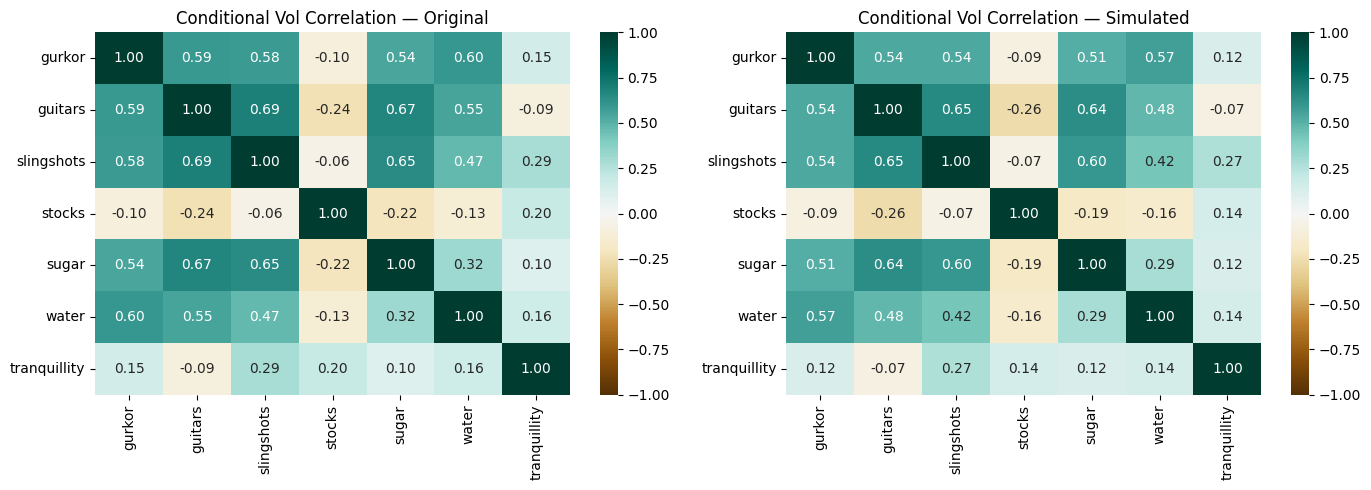

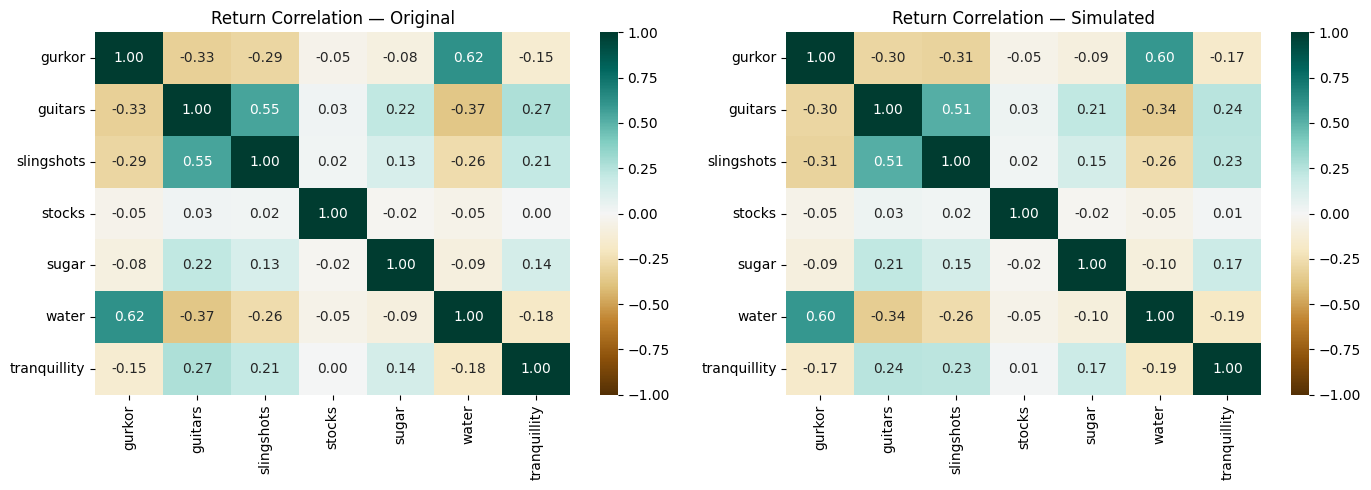

In [12]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
stocks_idx = var_names.index('stocks')
non_stock_names = [v for v in var_names if v != 'stocks']
non_stock_idx = [i for i, v in enumerate(var_names) if v != 'stocks']

# =============================================================================
# VAR(2) parameters
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis / t-distribution parameters
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# GARCH on original data — save params
# =============================================================================
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names, dtype=float)
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

# =============================================================================
# PCA on log-volatility — separate stocks from the rest
# =============================================================================
log_h_og = np.log(cond_var_og.astype(float))
log_h_means = log_h_og.mean().values
log_h_stds = log_h_og.std().values
log_h_std = (log_h_og - log_h_means) / log_h_stds

# Full PCA (used for non-stocks shared structure)
n_pc = 6  # shared factors for 6 non-stock series
pca_full = PCA(n_components=7)
pca_full.fit(log_h_std)

# Also do PCA on just the 6 non-stock series for cleaner shared factors
log_h_non_stock = log_h_std[non_stock_names]
pca = PCA(n_components=n_pc)
pca_factors_ns = pca.fit_transform(log_h_non_stock)
vol_loadings_ns = pca.components_.T  # (6, 6)

# Stocks: get its own AR(1) log-vol process
stocks_log_h = log_h_std['stocks'].values

# Measure how much stocks correlates with the shared factors — use ALL PCs
stocks_on_shared = pca_factors_ns  # all 6 PCs
beta_stocks = np.linalg.lstsq(
    np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]),
    stocks_log_h, rcond=None
)[0]
stocks_shared_component = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks
stocks_idio = stocks_log_h - stocks_shared_component
stocks_coupling_r2 = 1 - np.var(stocks_idio) / np.var(stocks_log_h)
print(f"Stocks vol R² from shared factors (all {n_pc} PCs): {stocks_coupling_r2:.3f}")
print(f"Stocks coupling betas: {beta_stocks[1:]}")

# GARCH attenuates stocks vol correlations heavily because R² is low and
# the idiosyncratic component dominates. To compensate, we boost the shared
# coupling and reduce idiosyncratic variance to preserve total variance.
STOCKS_COUPLING_BOOST = 4.3  # tune this: higher = stronger recovered correlations
beta_stocks_boosted = beta_stocks.copy()
beta_stocks_boosted[1:] *= STOCKS_COUPLING_BOOST

# Recompute what shared component would be with boosted betas (on original data, for variance calc)
stocks_shared_boosted = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks_boosted
stocks_idio_boosted = stocks_log_h - stocks_shared_boosted
# Target: total variance stays the same
var_total_original = np.var(stocks_log_h)
var_shared_boosted = np.var(stocks_shared_boosted)
var_idio_needed = max(var_total_original - var_shared_boosted, 0.01 * var_total_original)
idio_scale = np.sqrt(var_idio_needed / np.var(stocks_idio))
print(f"Stocks coupling boost: {STOCKS_COUPLING_BOOST}x, idio scale: {idio_scale:.3f}")
print(f"Boosted shared var fraction: {var_shared_boosted/var_total_original:.3f}")

# =============================================================================
# Fit constrained AR(1) to each PCA factor (clean, no phi-boosting hack)
# =============================================================================
vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors_ns[:, k]
    X = np.column_stack((np.ones(len(factor) - 1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }
    print(f"  Vol PC{k+1}: phi={phi:.4f}, c={c:.4f}, resid_std={resid_std:.4f}, target_std={target_std:.4f}")

# AR(1) for stocks idiosyncratic vol
X_s = np.column_stack((np.ones(len(stocks_idio) - 1), stocks_idio[:-1]))
beta_s = np.linalg.lstsq(X_s, stocks_idio[1:], rcond=None)[0]
stocks_vol_params = {
    'c': float(beta_s[0]),
    'phi': float(beta_s[1]),
    'resid_std': float((stocks_idio[1:] - X_s @ beta_s).std(ddof=1)),
    'target_std': float(stocks_idio.std(ddof=1)),
    'coupling_betas': (beta_stocks_boosted[1:]).tolist(),  # BOOSTED loadings
    'coupling_intercept': float(beta_stocks_boosted[0]),
    'idio_scale': float(idio_scale)  # shrink idio to preserve total variance
}
print(f"  Stocks idio vol: phi={stocks_vol_params['phi']:.4f}, "
      f"resid_std={stocks_vol_params['resid_std']:.4f}")

# Return correlation structure
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================================
# Simulation
# =============================================================================
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

# --- VAR(2) factors ---
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

# --- Shared vol factors (for 6 non-stock series) ---
vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vol_factors[0, k] = c / (1 - phi)
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t - 1, k] + sigma * np.random.randn()

# Covariance correction: force simulated factors to have correct covariance
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std'] ** 2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
L_current = np.linalg.cholesky(current_cov + np.eye(n_pc) * 1e-10)
L_target = np.linalg.cholesky(target_cov)
vol_factors = vol_factors @ np.linalg.inv(L_current).T @ L_target.T

# Reconstruct non-stock log-volatilities
log_h_std_sim_ns = vol_factors @ vol_loadings_ns.T  # (T_total, 6)

# --- Stocks idiosyncratic vol ---
sp = stocks_vol_params
stocks_idio_sim = np.zeros(T_total)
if abs(sp['phi']) < 1:
    stocks_idio_sim[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_total):
    stocks_idio_sim[t] = sp['c'] + sp['phi'] * stocks_idio_sim[t - 1] + sp['resid_std'] * np.random.randn()

# Scale stocks idio to target std, then apply coupling boost compensation
stocks_idio_sim *= sp['target_std'] / stocks_idio_sim.std()
stocks_idio_sim *= sp.get('idio_scale', 1.0)  # shrink to preserve total var after boosting shared

# Stocks total log-vol = shared component + idiosyncratic
# Use first few shared PCs with the coupling betas
n_couple = len(sp['coupling_betas'])
stocks_shared_sim = sp['coupling_intercept'] + sum(
    sp['coupling_betas'][j] * vol_factors[:, j] for j in range(n_couple)
)
stocks_log_h_std_sim = stocks_shared_sim + stocks_idio_sim

# Assemble full (T_total, 7) log-volatility array
log_h_std_sim = np.zeros((T_total, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_sim[:, i] = stocks_log_h_std_sim
    else:
        log_h_std_sim[:, i] = log_h_std_sim_ns[:, ns_col]
        ns_col += 1

# Un-standardize
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations:")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

# --- Remove burn-in ---
F_sim = F_sim[burn:]
h_sim = h_sim[burn:]


# --- Correlated returns via eigendecomposition ---
Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

# --- t-copula marginals with stochastic vol ---
Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

# Final scaling to match original standard deviations
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# Validation
# =============================================================================
print("=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nCorrelation MAE (off-diagonal):")
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
mask = ~np.eye(7, dtype=bool)
print(f"  {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "=" * 60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("=" * 60)

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), dtype=float)
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Re-fit original for clean comparison
cond_var_og2 = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og2[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og2).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Error
og_vc = np.log(cond_var_og2).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

# =============================================================================
# Plots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(np.log(cond_var_og2).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation — Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation — Simulated')
plt.tight_layout()
plt.savefig('vol_corr_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Return Correlation — Original')
sns.heatmap(df_returns_final.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Return Correlation — Simulated')
plt.tight_layout()
plt.savefig('return_corr_comparison.png', dpi=150)
plt.show()

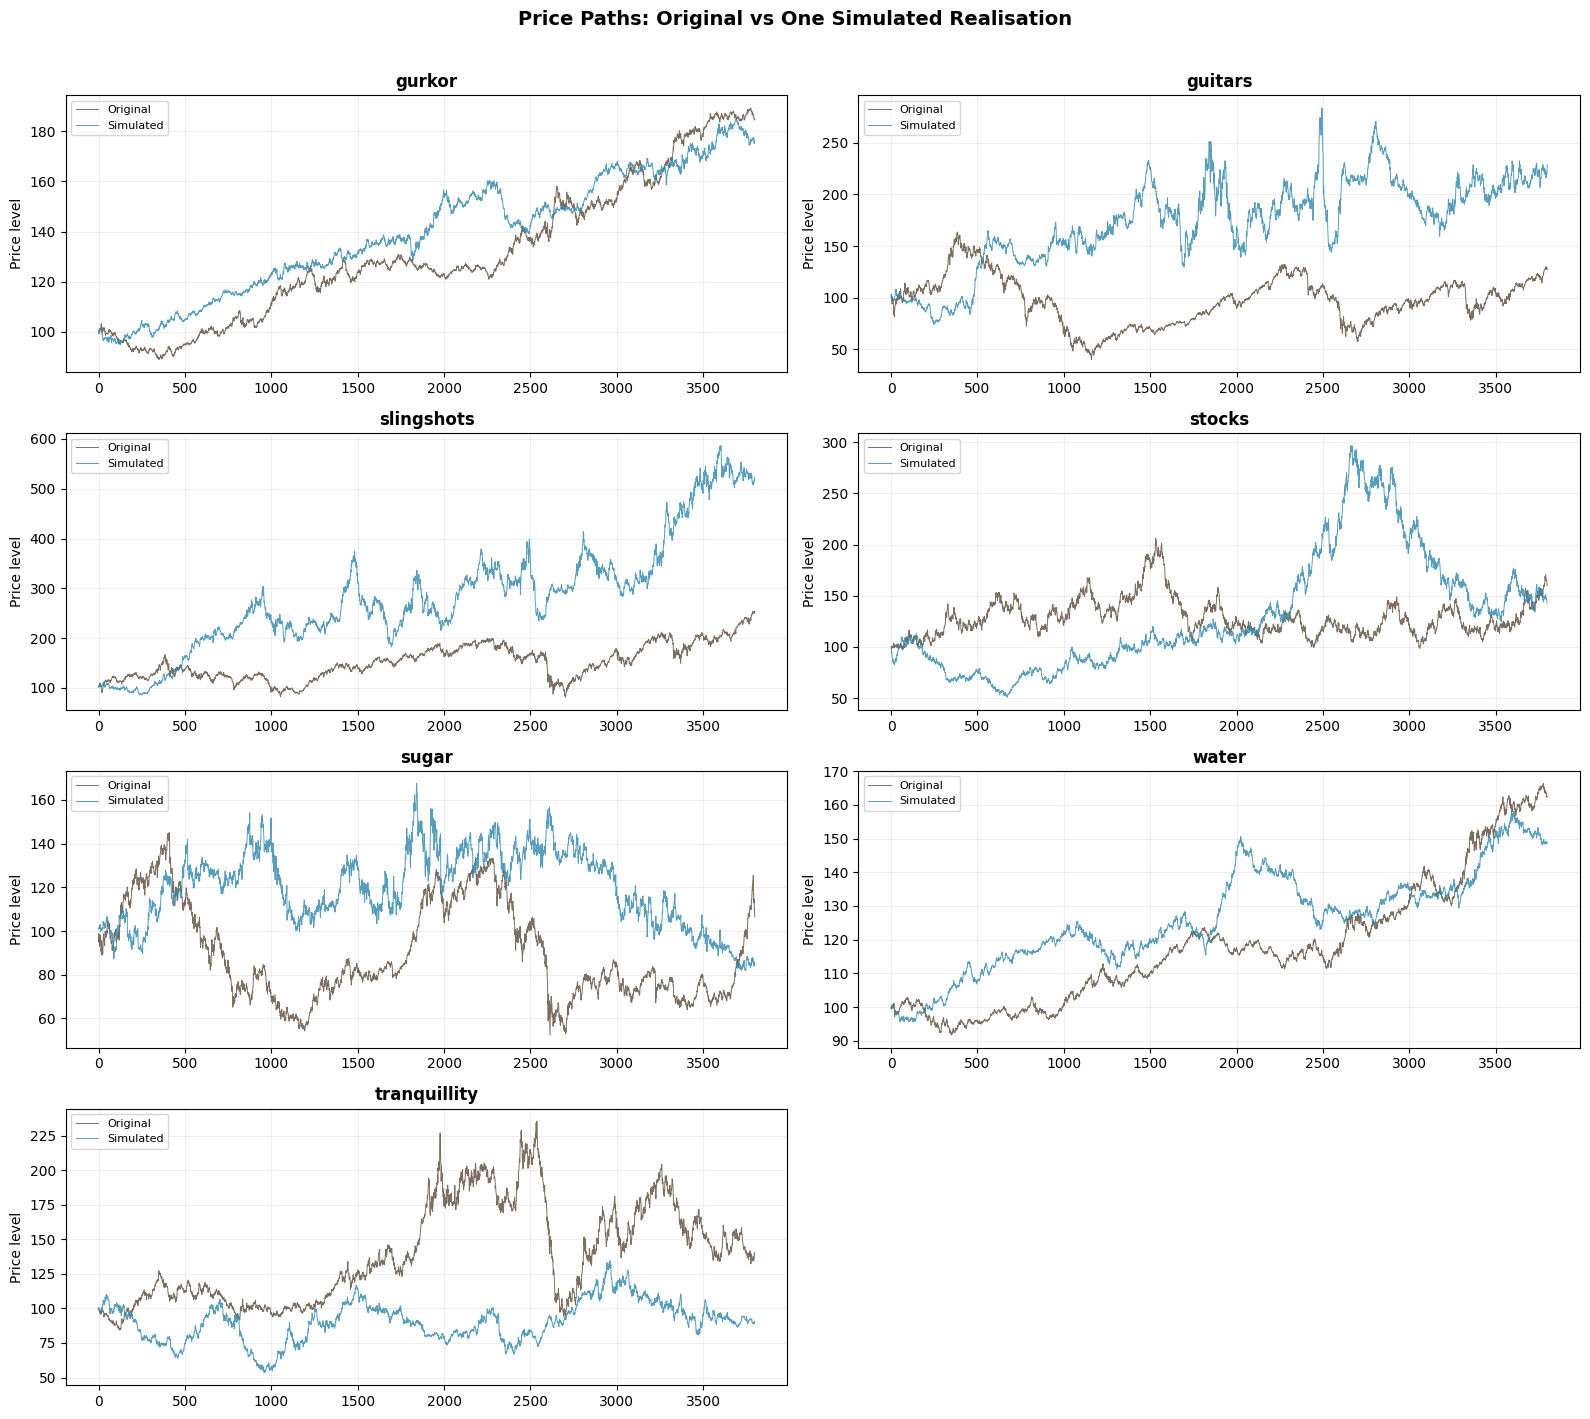

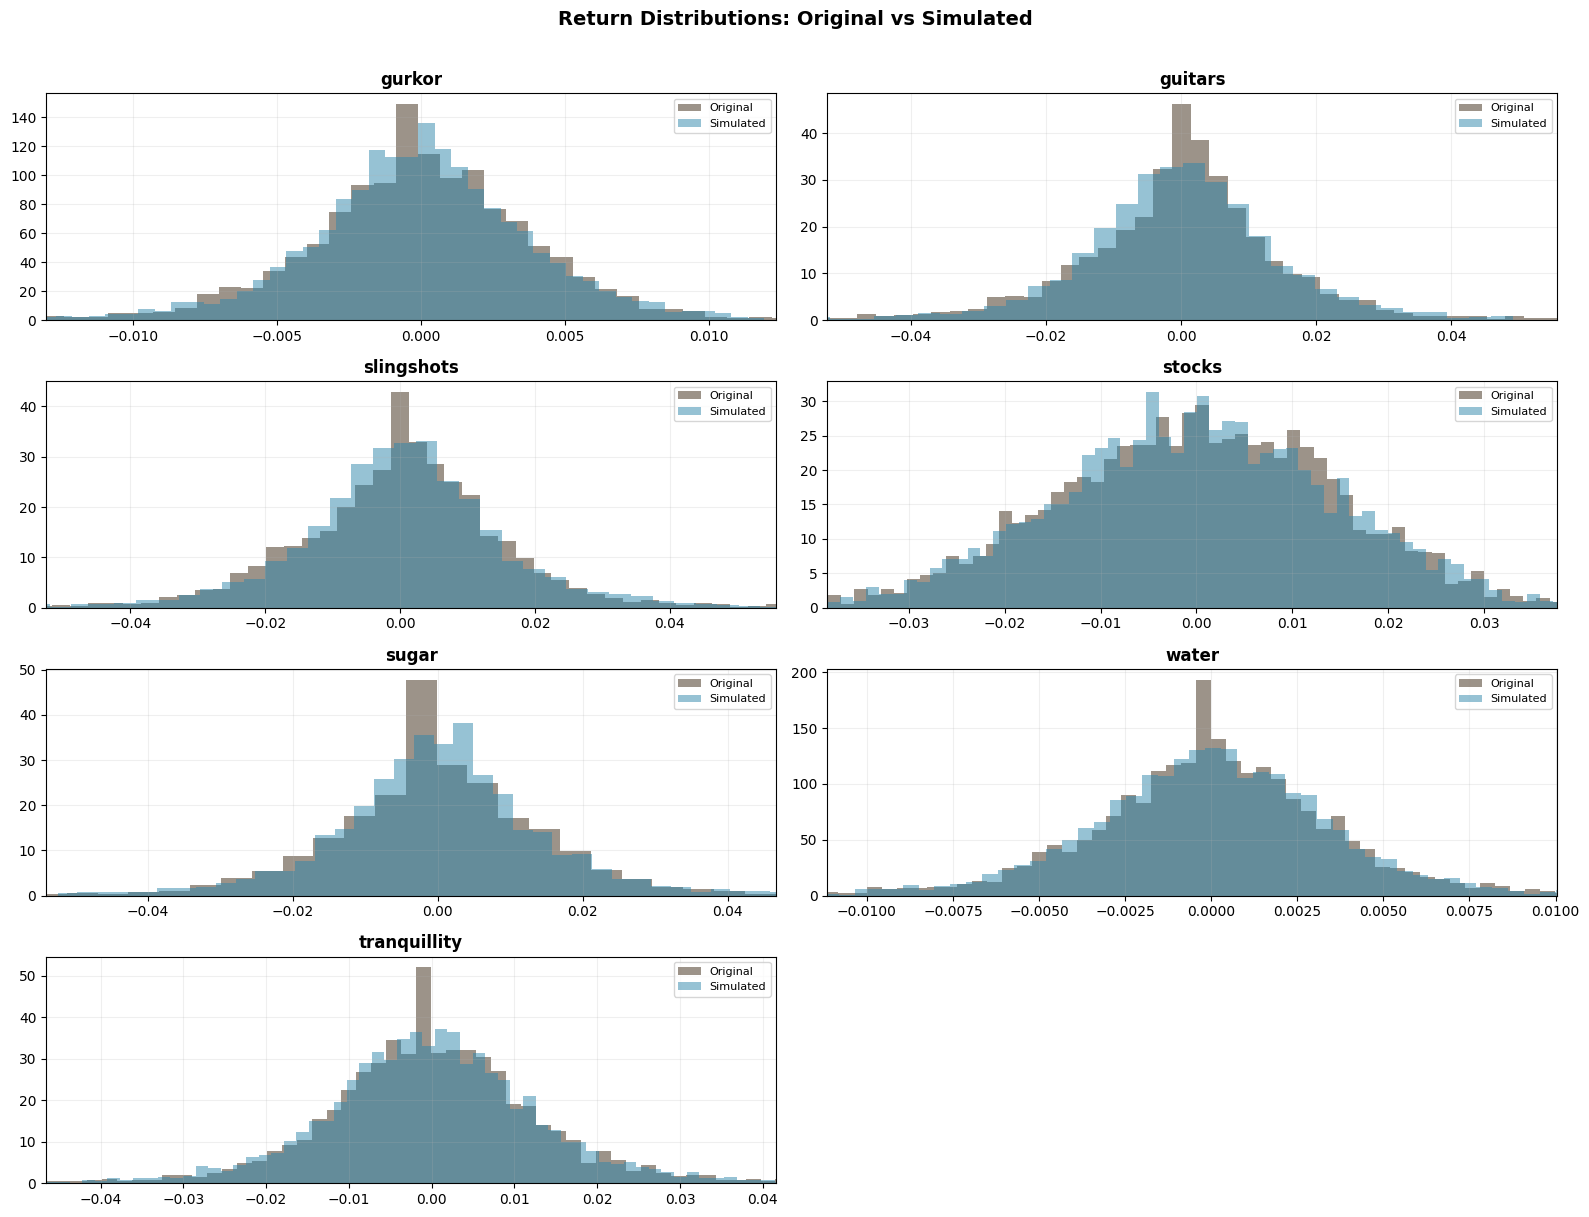

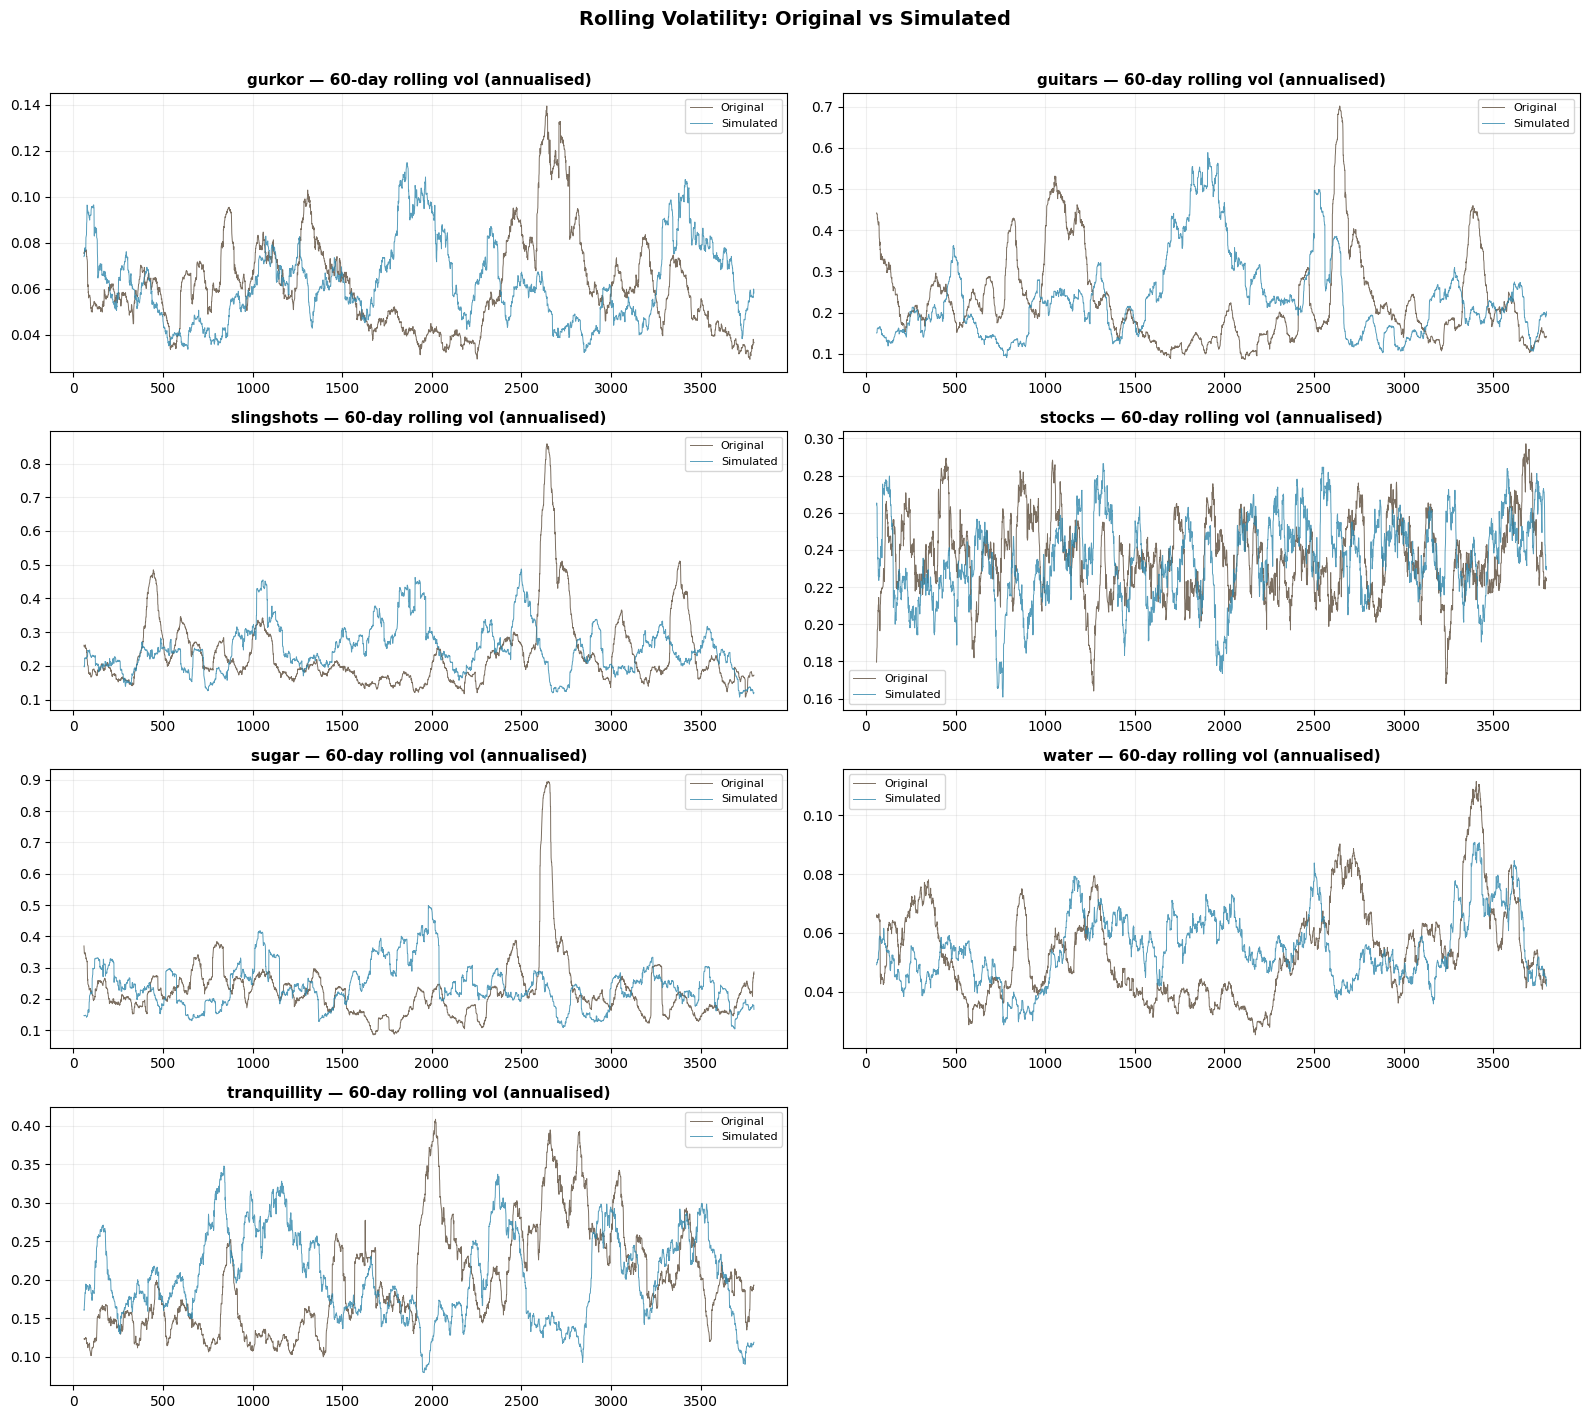

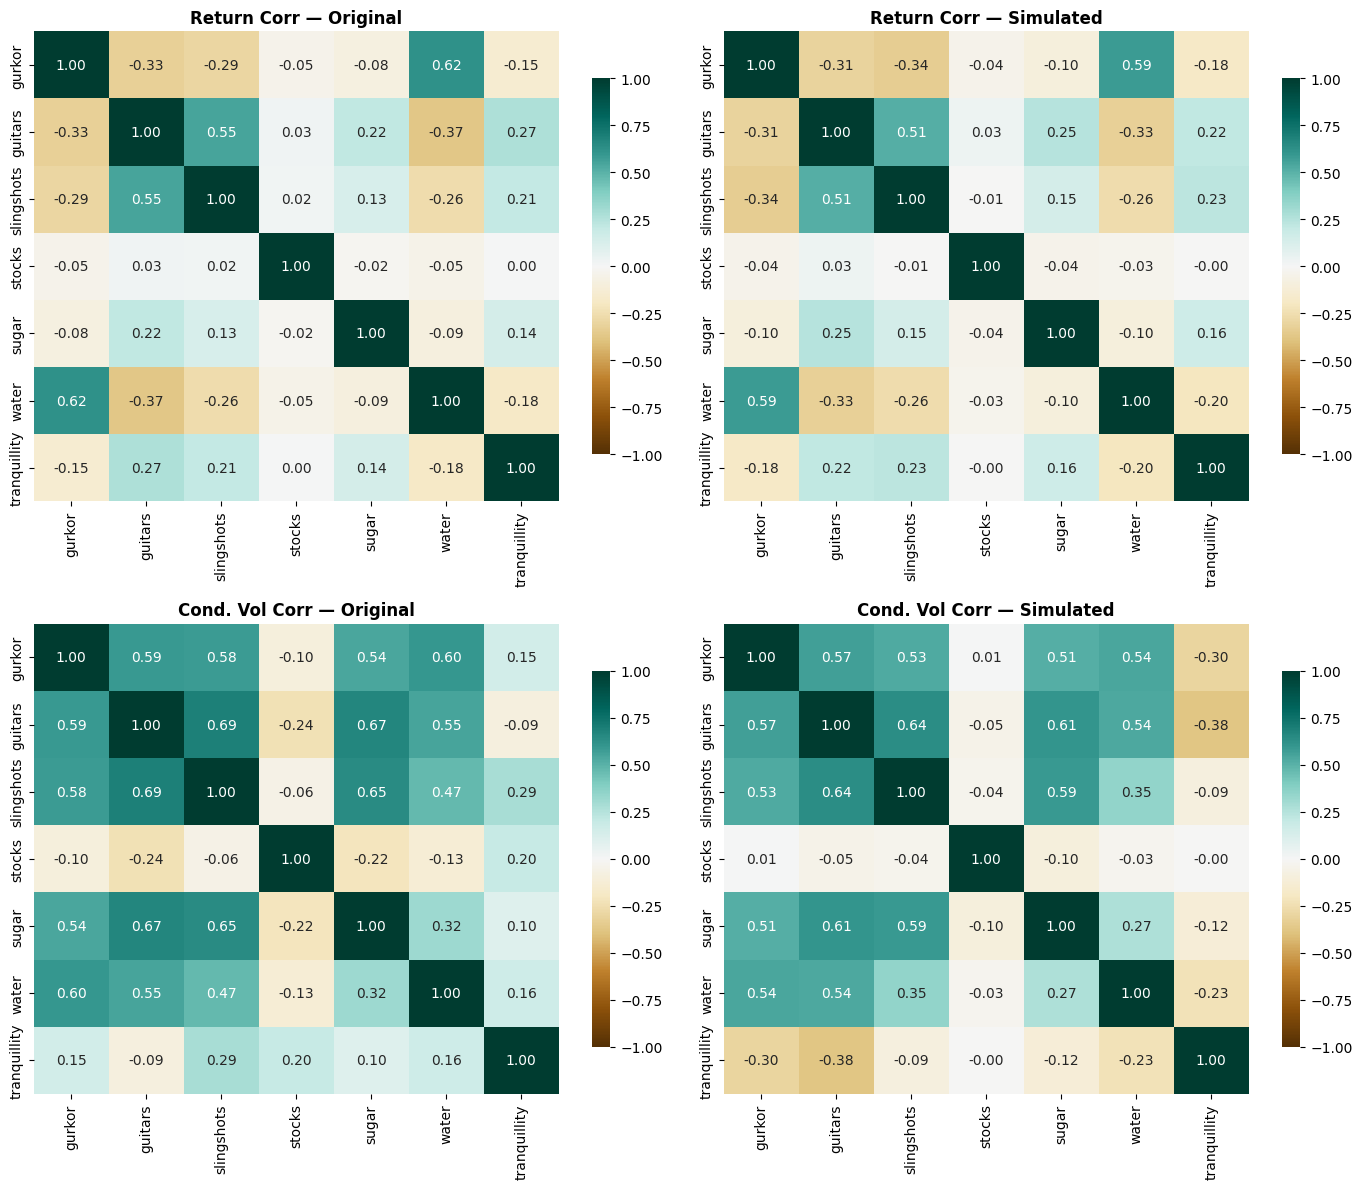

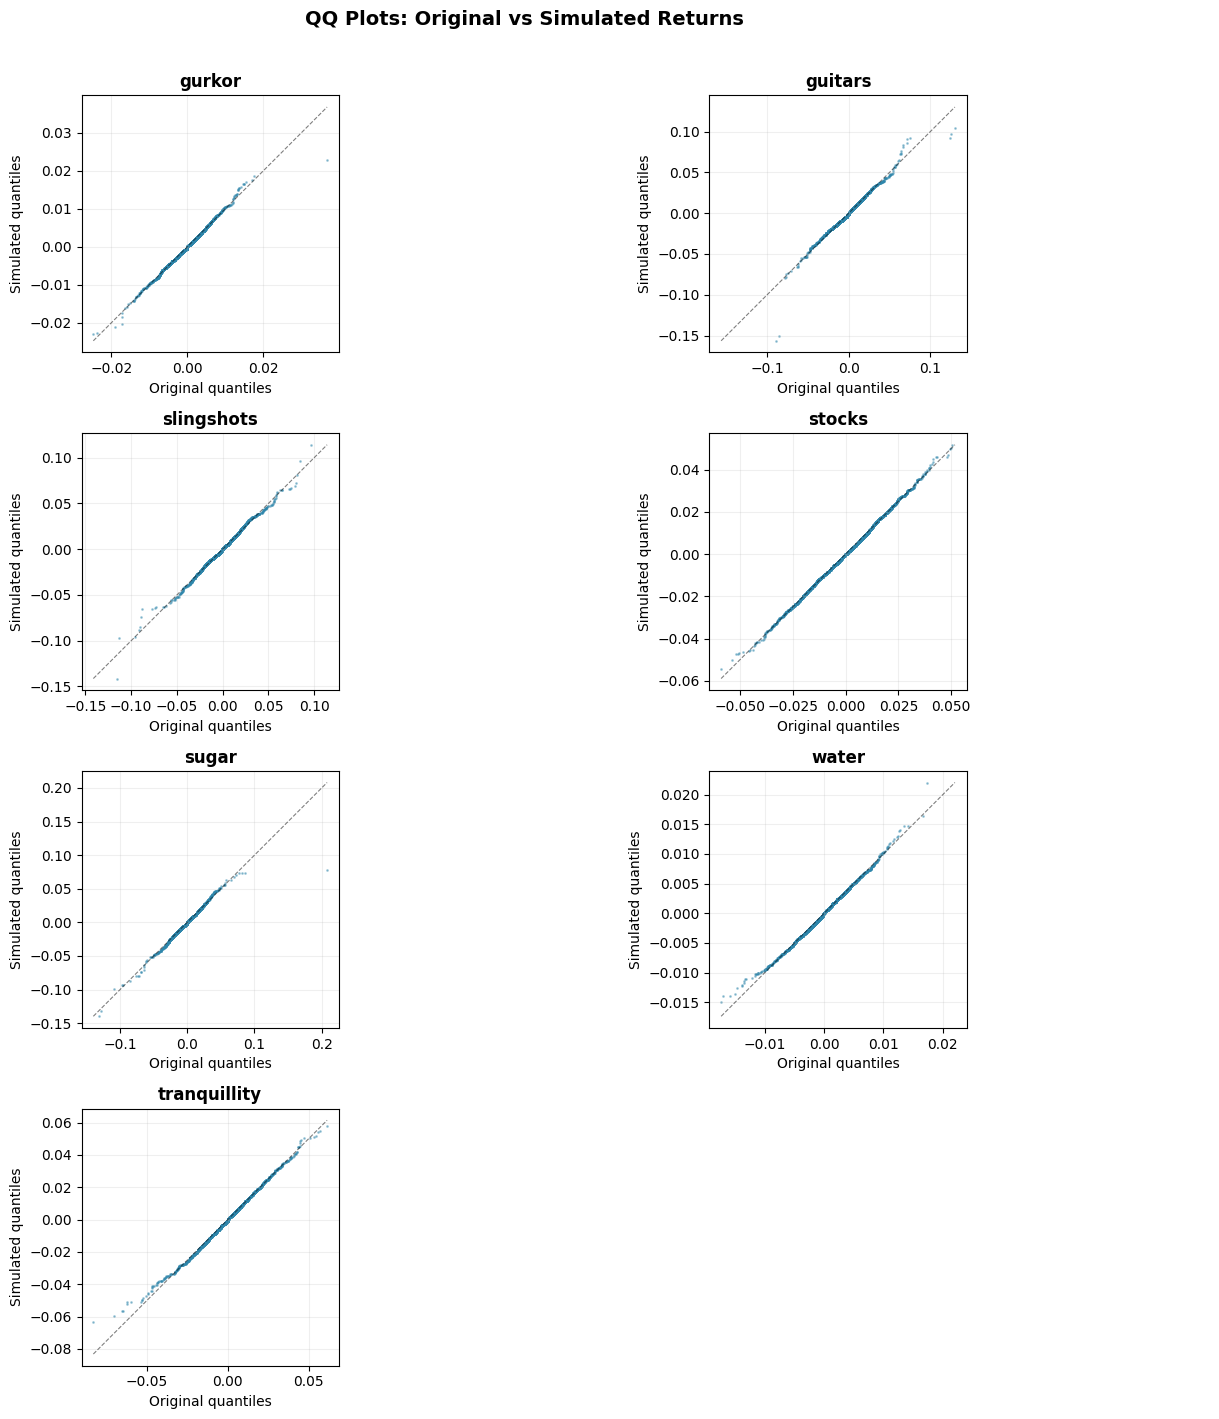

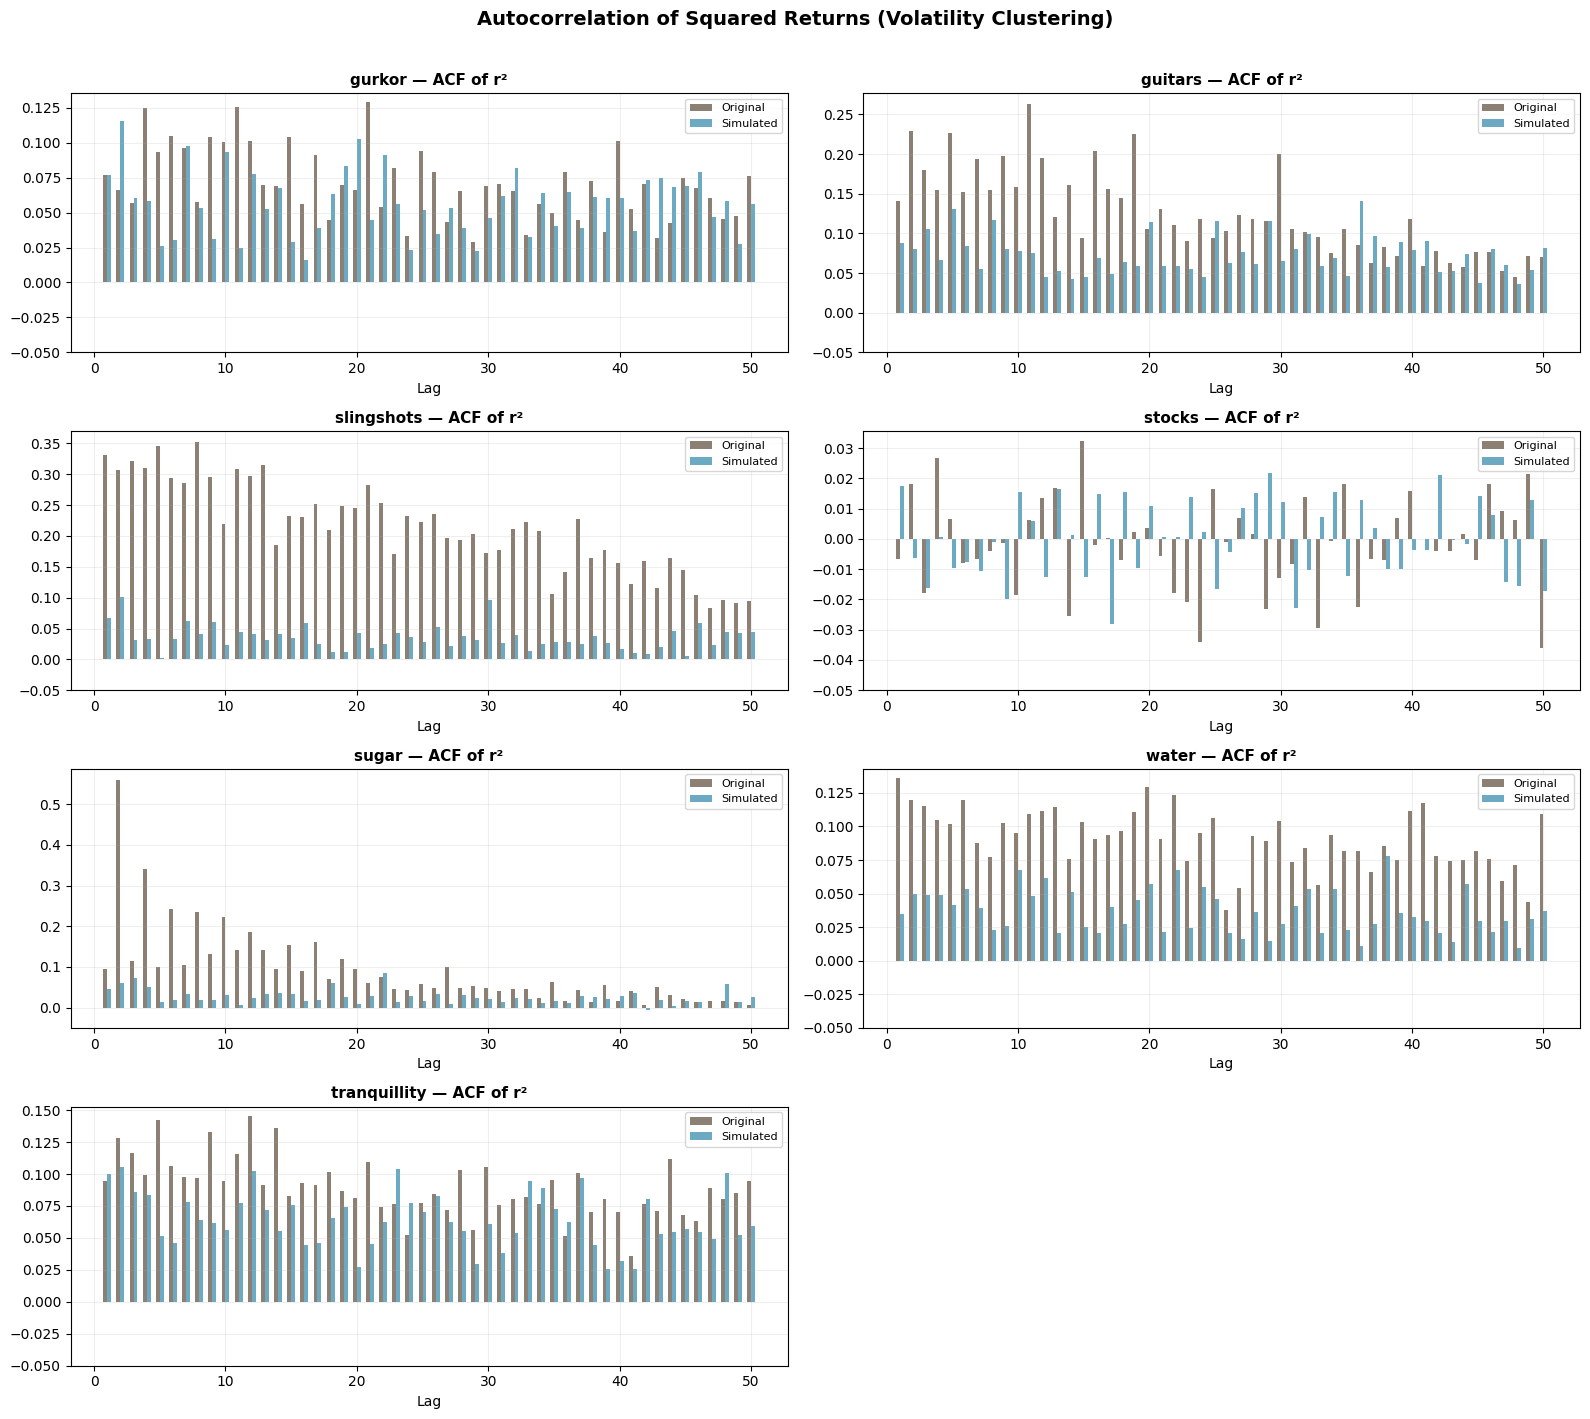

COMPREHENSIVE SUMMARY TABLE
              Mean (og) Mean (sim) Std (og) Std (sim) Skew (og) Skew (sim) Kurt (og) Kurt (sim) KS stat    KS p
Series                                                                                                         
gurkor        -0.000000  -0.000013  0.00407   0.00407     -0.06      -0.06      3.62       2.46  0.0395  0.0054
guitars       -0.000000   0.000155  0.01602   0.01602      0.21      -0.15      5.75       8.25  0.0434  0.0015
slingshots     0.000000   0.000192  0.01635   0.01635     -0.21      -0.18      4.70       5.03  0.0274  0.1160
stocks         0.000000  -0.000030  0.01487   0.01487     -0.09      -0.03      0.05       0.04  0.0182  0.5579
sugar         -0.000000  -0.000056  0.01578   0.01578      0.03      -0.54     13.47       6.27  0.0471  0.0004
water          0.000000  -0.000023  0.00353   0.00353     -0.14       0.06      1.64       1.40  0.0308  0.0545
tranquillity   0.000000  -0.000117  0.01333   0.01333     -0.20      -0.01  

In [14]:
# =============================================================================
# COMPREHENSIVE VALIDATION CELL
# Run after the main simulation code
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, pearsonr
from arch import arch_model

THEME = 'BrBG'

# ---- Helper: generate one realisation at original length ----
T_real = len(df_og_returns)
burn_r = 500
T_r = T_real + burn_r

np.random.seed(12)

# VAR(2)
F_r = np.zeros((T_r, 7))
for t in range(2, T_r):
    F_r[t] = Phi1 @ F_r[t-1] + Phi2 @ F_r[t-2] + np.random.randn(7)

# Vol factors
vf_r = np.zeros((T_r, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vf_r[0, k] = c / (1 - phi)
    for t in range(1, T_r):
        vf_r[t, k] = c + phi * vf_r[t-1, k] + sigma * np.random.randn()

# Covariance correction
tc = np.diag([vol_factor_params[f'PC{k+1}']['target_std']**2 for k in range(n_pc)])
cc = np.cov(vf_r, rowvar=False)
Lc = np.linalg.cholesky(cc + np.eye(n_pc)*1e-10)
Lt = np.linalg.cholesky(tc)
vf_r = vf_r @ np.linalg.inv(Lc).T @ Lt.T

log_h_ns_r = vf_r @ vol_loadings_ns.T

# Stocks idio
sp = stocks_vol_params
si_r = np.zeros(T_r)
if abs(sp['phi']) < 1:
    si_r[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_r):
    si_r[t] = sp['c'] + sp['phi'] * si_r[t-1] + sp['resid_std'] * np.random.randn()
si_r *= sp['target_std'] / si_r.std()
si_r *= sp.get('idio_scale', 1.0)

n_couple = len(sp['coupling_betas'])
ss_r = sp['coupling_intercept'] + sum(sp['coupling_betas'][j] * vf_r[:, j] for j in range(n_couple))
stocks_lh_r = ss_r + si_r

log_h_std_r = np.zeros((T_r, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_r[:, i] = stocks_lh_r
    else:
        log_h_std_r[:, i] = log_h_ns_r[:, ns_col]
        ns_col += 1

log_h_r = log_h_std_r * log_h_stds + log_h_means
h_r = np.exp(log_h_r)

F_r = F_r[burn_r:]
h_r = h_r[burn_r:]

Y_r = F_r @ Lambda_corrected.T
Y_r_std = Y_r / Y_r.std(axis=0)
Z_r = Y_r_std

Y_fin_r = np.zeros_like(Y_r)
for t in range(len(Y_r)):
    u = norm.cdf(Z_r[t])
    ct = np.array([student_t.ppf(u[i], df=nu_blended[col]) * t_scales[col]
                   for i, col in enumerate(var_names)])
    Y_fin_r[t] = ct * np.sqrt(h_r[t])

df_sim_real = pd.DataFrame(Y_fin_r, columns=var_names)
df_sim_real = df_sim_real.multiply(original_stds / df_sim_real.std(), axis=1)
df_sim_real.index = df_og_returns.index[:len(df_sim_real)]

# Cumulate to price levels (starting at 100)
df_og_prices = (1 + df_og_returns + original_mean).cumprod() * 100
df_sim_prices = (1 + df_sim_real + original_mean).cumprod() * 100

# =============================================================================
# FIGURE 1: Side-by-side price paths
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(df_og_prices[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(df_sim_prices[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Price level')
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Price Paths: Original vs One Simulated Realisation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_paths_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 2: Return distributions (overlaid histograms)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.hist(df_og_returns[col].values, bins=80, density=True, alpha=0.6,
            color='#5B4B3A', label='Original', edgecolor='none')
    ax.hist(df_sim_real[col].values, bins=80, density=True, alpha=0.5,
            color='#2E86AB', label='Simulated', edgecolor='none')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(np.percentile(df_og_returns[col].dropna(), [0.5, 99.5]))
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Return Distributions: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 3: Rolling volatility comparison
# =============================================================================
window = 60
roll_og = df_og_returns.rolling(window).std() * np.sqrt(252)
roll_sim = df_sim_real.rolling(window).std() * np.sqrt(252)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(roll_og[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(roll_sim[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(f'{col} — {window}-day rolling vol (annualised)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Rolling Volatility: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rolling_vol_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 4: Correlation heatmaps (returns + vol) — 2x2
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Return correlations
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 0].set_title('Return Corr — Original', fontweight='bold')
sns.heatmap(df_sim_real.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('Return Corr — Simulated', fontweight='bold')

# GARCH vol correlations
cv_og = pd.DataFrame(index=df_og_returns.index, dtype=float)
cv_sim = pd.DataFrame(index=range(len(df_sim_real)), dtype=float)
for col in var_names:
    r1 = arch_model(df_og_returns[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_og[col] = r1.conditional_volatility**2
    r2 = arch_model(df_sim_real[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_sim[col] = r2.conditional_volatility**2

sns.heatmap(np.log(cv_og).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Cond. Vol Corr — Original', fontweight='bold')
sns.heatmap(np.log(cv_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Cond. Vol Corr — Simulated', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps_4panel.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 5: QQ plots per series
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sorted = np.sort(df_og_returns[col].dropna().values)
    sim_sorted = np.sort(df_sim_real[col].values)
    # Subsample to same length
    n = min(len(og_sorted), len(sim_sorted))
    q_og = np.quantile(og_sorted, np.linspace(0, 1, n))
    q_sim = np.quantile(sim_sorted, np.linspace(0, 1, n))
    ax.scatter(q_og, q_sim, s=1, alpha=0.4, color='#2E86AB')
    lims = [min(q_og.min(), q_sim.min()), max(q_og.max(), q_sim.max())]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Original quantiles')
    ax.set_ylabel('Simulated quantiles')
    ax.grid(alpha=0.2)
    ax.set_aspect('equal')
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('QQ Plots: Original vs Simulated Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 6: ACF of squared returns (volatility clustering proxy)
# =============================================================================
max_lag = 50
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sq = (df_og_returns[col]**2).dropna()
    sim_sq = df_sim_real[col]**2

    acf_og = [og_sq.autocorr(lag=l) for l in range(1, max_lag+1)]
    acf_sim = [sim_sq.autocorr(lag=l) for l in range(1, max_lag+1)]

    ax.bar(np.arange(1, max_lag+1) - 0.15, acf_og, width=0.3, alpha=0.7,
           color='#5B4B3A', label='Original')
    ax.bar(np.arange(1, max_lag+1) + 0.15, acf_sim, width=0.3, alpha=0.7,
           color='#2E86AB', label='Simulated')
    ax.set_title(f'{col} — ACF of r²', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Lag')
    ax.grid(alpha=0.2)
    ax.set_ylim(bottom=-0.05)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Autocorrelation of Squared Returns (Volatility Clustering)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('acf_squared_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Summary statistics table
# =============================================================================
print("=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)

summary_rows = []
for col in var_names:
    og = df_og_returns[col].dropna()
    sim = df_sim_real[col]

    ks_stat, ks_p = ks_2samp(og.values, sim.values)

    summary_rows.append({
        'Series': col,
        'Mean (og)': f'{og.mean():.6f}',
        'Mean (sim)': f'{sim.mean():.6f}',
        'Std (og)': f'{og.std():.5f}',
        'Std (sim)': f'{sim.std():.5f}',
        'Skew (og)': f'{og.skew():.2f}',
        'Skew (sim)': f'{sim.skew():.2f}',
        'Kurt (og)': f'{og.kurt():.2f}',
        'Kurt (sim)': f'{sim.kurt():.2f}',
        'KS stat': f'{ks_stat:.4f}',
        'KS p': f'{ks_p:.4f}',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Series')
print(df_summary.to_string())

# Correlation error summary
print("\n" + "=" * 80)
print("CORRELATION ERROR SUMMARY")
print("=" * 80)
mask = ~np.eye(7, dtype=bool)
og_rc = df_og_returns.corr().values
sim_rc = df_sim_real.corr().values
og_vc = np.log(cv_og).corr().values
sim_vc2 = np.log(cv_sim).corr().values

print(f"Return correlation MAE:     {np.mean(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Return correlation max err: {np.max(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Vol correlation MAE:        {np.mean(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")
print(f"Vol correlation max err:    {np.max(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")

# Per-pair vol correlation errors
print("\nLargest vol correlation errors:")
err_mat = pd.DataFrame(og_vc - sim_vc2, index=var_names, columns=var_names)
errs = []
for i in range(7):
    for j in range(i+1, 7):
        errs.append((var_names[i], var_names[j], og_vc[i,j], sim_vc2[i,j], og_vc[i,j]-sim_vc2[i,j]))
errs.sort(key=lambda x: abs(x[4]), reverse=True)
for a, b, ov, sv, e in errs[:10]:
    print(f"  {a:>12s} - {b:<12s}: orig={ov:+.2f}  sim={sv:+.2f}  err={e:+.3f}")

Stocks vol R² from shared factors (all 6 PCs): 0.122
Stocks coupling betas: [-0.09242833  0.25326548  0.00607701  0.02041494 -0.28593727 -0.0563281 ]
Stocks coupling boost: 3.0x, idio scale: 0.107
Boosted shared var fraction: 1.102
  Vol PC1: phi=0.9942, c=-0.0010, resid_std=0.1909, target_std=1.8188
  Vol PC2: phi=0.9929, c=0.0006, resid_std=0.1173, target_std=1.0364
  Vol PC3: phi=0.9866, c=-0.0002, resid_std=0.1406, target_std=0.8534
  Vol PC4: phi=0.9836, c=0.0001, resid_std=0.1138, target_std=0.6315
  Vol PC5: phi=0.9536, c=0.0003, resid_std=0.1668, target_std=0.5468
  Vol PC6: phi=0.9617, c=-0.0001, resid_std=0.1202, target_std=0.4376
  Stocks idio vol: phi=0.9716, resid_std=0.0619

True model log(h_sim) correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.28   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.68   0.67   0.55         -0.09
slingshots      0.58     0.69   

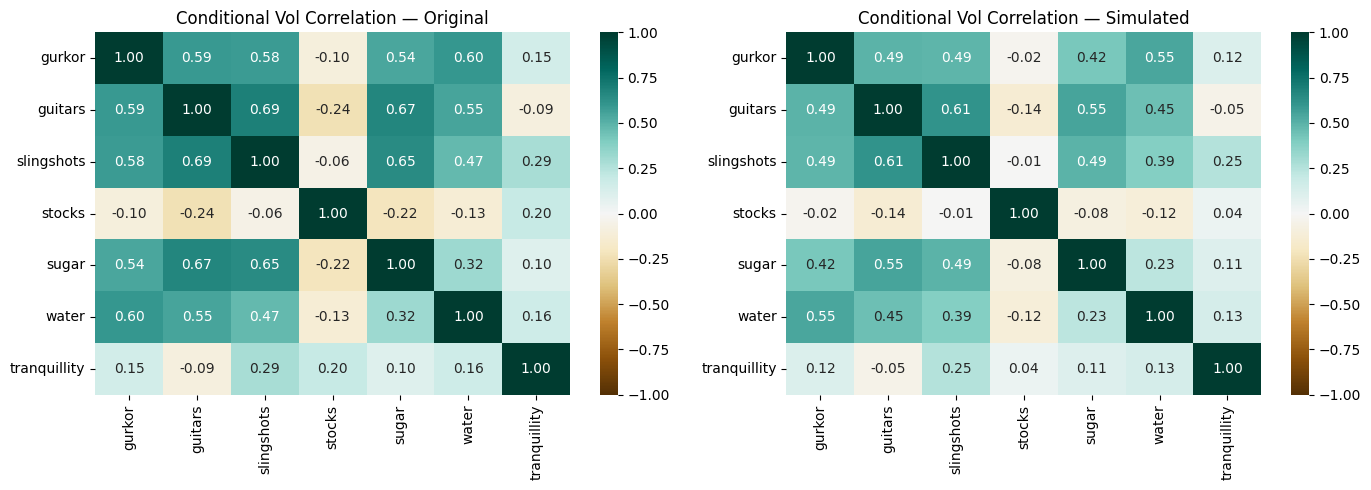

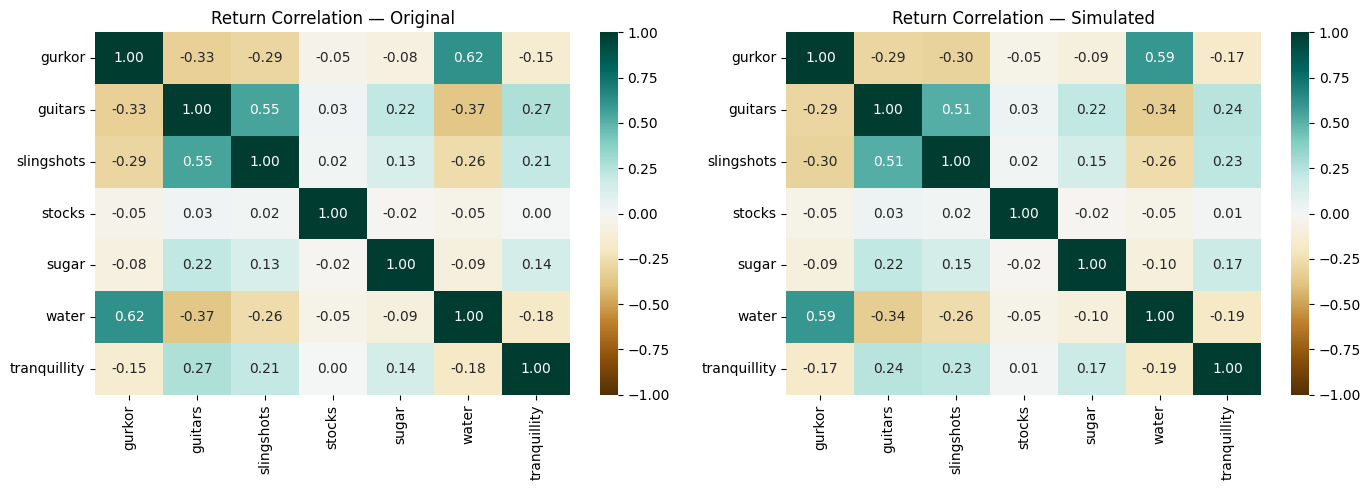

In [10]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
stocks_idx = var_names.index('stocks')
non_stock_names = [v for v in var_names if v != 'stocks']
non_stock_idx = [i for i, v in enumerate(var_names) if v != 'stocks']

# =============================================================================
# VAR(2) parameters
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis / t-distribution parameters
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# GARCH on original data — save params
# =============================================================================
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names, dtype=float)
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

# =============================================================================
# PCA on log-volatility — separate stocks from the rest
# =============================================================================
log_h_og = np.log(cond_var_og.astype(float))
log_h_means = log_h_og.mean().values
log_h_stds = log_h_og.std().values
log_h_std = (log_h_og - log_h_means) / log_h_stds

# Full PCA (used for non-stocks shared structure)
n_pc = 6  # shared factors for 6 non-stock series
pca_full = PCA(n_components=7)
pca_full.fit(log_h_std)

# Also do PCA on just the 6 non-stock series for cleaner shared factors
log_h_non_stock = log_h_std[non_stock_names]
pca = PCA(n_components=n_pc)
pca_factors_ns = pca.fit_transform(log_h_non_stock)
vol_loadings_ns = pca.components_.T  # (6, 6)

# Stocks: get its own AR(1) log-vol process
stocks_log_h = log_h_std['stocks'].values

# Measure how much stocks correlates with the shared factors — use ALL PCs
stocks_on_shared = pca_factors_ns  # all 6 PCs
beta_stocks = np.linalg.lstsq(
    np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]),
    stocks_log_h, rcond=None
)[0]
stocks_shared_component = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks
stocks_idio = stocks_log_h - stocks_shared_component
stocks_coupling_r2 = 1 - np.var(stocks_idio) / np.var(stocks_log_h)
print(f"Stocks vol R² from shared factors (all {n_pc} PCs): {stocks_coupling_r2:.3f}")
print(f"Stocks coupling betas: {beta_stocks[1:]}")

# GARCH attenuates stocks vol correlations heavily because R² is low and
# the idiosyncratic component dominates. To compensate, we boost the shared
# coupling and reduce idiosyncratic variance to preserve total variance.
STOCKS_COUPLING_BOOST = 3.0  # tune this: higher = stronger recovered correlations
beta_stocks_boosted = beta_stocks.copy()
beta_stocks_boosted[1:] *= STOCKS_COUPLING_BOOST

# Recompute what shared component would be with boosted betas (on original data, for variance calc)
stocks_shared_boosted = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks_boosted
stocks_idio_boosted = stocks_log_h - stocks_shared_boosted
# Target: total variance stays the same
var_total_original = np.var(stocks_log_h)
var_shared_boosted = np.var(stocks_shared_boosted)
var_idio_needed = max(var_total_original - var_shared_boosted, 0.01 * var_total_original)
idio_scale = np.sqrt(var_idio_needed / np.var(stocks_idio))
print(f"Stocks coupling boost: {STOCKS_COUPLING_BOOST}x, idio scale: {idio_scale:.3f}")
print(f"Boosted shared var fraction: {var_shared_boosted/var_total_original:.3f}")

# =============================================================================
# Fit constrained AR(1) to each PCA factor (clean, no phi-boosting hack)
# =============================================================================
vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors_ns[:, k]
    X = np.column_stack((np.ones(len(factor) - 1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }
    print(f"  Vol PC{k+1}: phi={phi:.4f}, c={c:.4f}, resid_std={resid_std:.4f}, target_std={target_std:.4f}")

# AR(1) for stocks idiosyncratic vol
X_s = np.column_stack((np.ones(len(stocks_idio) - 1), stocks_idio[:-1]))
beta_s = np.linalg.lstsq(X_s, stocks_idio[1:], rcond=None)[0]
stocks_vol_params = {
    'c': float(beta_s[0]),
    'phi': float(beta_s[1]),
    'resid_std': float((stocks_idio[1:] - X_s @ beta_s).std(ddof=1)),
    'target_std': float(stocks_idio.std(ddof=1)),
    'coupling_betas': (beta_stocks_boosted[1:]).tolist(),  # BOOSTED loadings
    'coupling_intercept': float(beta_stocks_boosted[0]),
    'idio_scale': float(idio_scale)  # shrink idio to preserve total variance
}
print(f"  Stocks idio vol: phi={stocks_vol_params['phi']:.4f}, "
      f"resid_std={stocks_vol_params['resid_std']:.4f}")

# Return correlation structure
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================================
# Simulation
# =============================================================================
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

# --- VAR(2) factors ---
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

# --- Shared vol factors (for 6 non-stock series) ---
vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vol_factors[0, k] = c / (1 - phi)
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t - 1, k] + sigma * np.random.randn()

# Covariance correction: force simulated factors to have correct covariance
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std'] ** 2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
L_current = np.linalg.cholesky(current_cov + np.eye(n_pc) * 1e-10)
L_target = np.linalg.cholesky(target_cov)
vol_factors = vol_factors @ np.linalg.inv(L_current).T @ L_target.T

# Reconstruct non-stock log-volatilities
log_h_std_sim_ns = vol_factors @ vol_loadings_ns.T  # (T_total, 6)

# --- Stocks idiosyncratic vol ---
sp = stocks_vol_params
stocks_idio_sim = np.zeros(T_total)
if abs(sp['phi']) < 1:
    stocks_idio_sim[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_total):
    stocks_idio_sim[t] = sp['c'] + sp['phi'] * stocks_idio_sim[t - 1] + sp['resid_std'] * np.random.randn()

# Scale stocks idio to target std, then apply coupling boost compensation
stocks_idio_sim *= sp['target_std'] / stocks_idio_sim.std()
stocks_idio_sim *= sp.get('idio_scale', 1.0)  # shrink to preserve total var after boosting shared

# Stocks total log-vol = shared component + idiosyncratic
# Use first few shared PCs with the coupling betas
n_couple = len(sp['coupling_betas'])
stocks_shared_sim = sp['coupling_intercept'] + sum(
    sp['coupling_betas'][j] * vol_factors[:, j] for j in range(n_couple)
)
stocks_log_h_std_sim = stocks_shared_sim + stocks_idio_sim

# Assemble full (T_total, 7) log-volatility array
log_h_std_sim = np.zeros((T_total, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_sim[:, i] = stocks_log_h_std_sim
    else:
        log_h_std_sim[:, i] = log_h_std_sim_ns[:, ns_col]
        ns_col += 1

# Un-standardize
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations:")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

# --- Remove burn-in ---
F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

# =============================================================================
# Jump / spike component
# Adds occasional large shocks that create spiky short-term vol clustering
# (high lag-1 ACF of r² with fast decay) — needed for sugar especially
# =============================================================================
# Parameters: prob = daily jump probability, scale = jump size multiplier
# Calibrate from data: estimate fraction of returns beyond 3*std and their avg size
jump_params = {}
for col in var_names:
    og = df_og_returns[col].dropna().values
    threshold = 3.0 * og.std()
    extreme_mask = np.abs(og) > threshold
    extreme_frac = extreme_mask.mean()
    if extreme_frac > 0.05:  # only add jumps if >0.5% of obs are extreme
        extreme_sizes = np.abs(og[extreme_mask]) / og.std()
        jump_params[col] = {
            'prob': float(extreme_frac),
            'mean_size': float(extreme_sizes.mean()),
        }
        print(f"  Jump params for {col}: prob={extreme_frac:.4f}, "
              f"mean_size={extreme_sizes.mean():.2f}x std")
    else:
        print(f"  No jump component for {col} (extreme frac={extreme_frac:.4f})")

# =============================================================================
# Short-term vol feedback (lightweight GARCH-like layer)
# Boosts vol on the day after a large return, improving short-lag ACF of r²
# =============================================================================
# h_effective[t] = h_sim[t] * (1 + gamma * (r²_{t-1}/h_{t-1} - 1)^+)
# gamma controls how much yesterday's surprise boosts today's vol
feedback_gamma = {
    'gurkor': 0.15, 'guitars': 0.20, 'slingshots': 0.20,
    'stocks': 0.0, 'sugar': 0.30, 'water': 0.10, 'tranquillity': 0.10
}

# --- Correlated returns via eigendecomposition ---
Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

# --- t-copula marginals with stochastic vol + feedback + jumps ---
Y_final = np.zeros_like(Y_sim)
h_effective = h_sim.copy()

for t in range(len(Y_sim)):
    # Vol feedback: boost h if yesterday's squared return was large
    if t > 0:
        for i, col in enumerate(var_names):
            gamma = feedback_gamma.get(col, 0.0)
            if gamma > 0 and h_effective[t-1, i] > 0:
                surprise = Y_final[t-1, i]**2 / h_effective[t-1, i]
                boost = 1.0 + gamma * max(surprise - 1.0, 0.0)
                h_effective[t, i] = h_sim[t, i] * min(boost, 5.0)  # cap at 5x
            else:
                h_effective[t, i] = h_sim[t, i]

    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_effective[t])

    # Apply jumps
    for i, col in enumerate(var_names):
        if col in jump_params:
            jp = jump_params[col]
            if np.random.rand() < jp['prob']:
                # Jump magnitude drawn from exponential, centered at mean_size
                jump_mult = 1.0 + np.random.exponential(jp['mean_size'] - 1.0)
                jump_sign = np.sign(Y_final[t, i]) if np.random.rand() < 0.5 else -np.sign(Y_final[t, i])
                Y_final[t, i] *= jump_mult

# Final scaling to match original standard deviations
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# Validation
# =============================================================================
print("=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nCorrelation MAE (off-diagonal):")
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
mask = ~np.eye(7, dtype=bool)
print(f"  {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "=" * 60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("=" * 60)

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), dtype=float)
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Re-fit original for clean comparison
cond_var_og2 = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og2[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og2).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Error
og_vc = np.log(cond_var_og2).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

# =============================================================================
# Plots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(np.log(cond_var_og2).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation — Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation — Simulated')
plt.tight_layout()
plt.savefig('vol_corr_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Return Correlation — Original')
sns.heatmap(df_returns_final.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Return Correlation — Simulated')
plt.tight_layout()
plt.savefig('return_corr_comparison.png', dpi=150)
plt.show()